In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Data/Resume.csv")

# Display first 5 rows
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# Keep only the required columns
df = df[["Resume_str", "Category"]]

df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (2484, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Resume_str  2484 non-null   object
 1   Category    2484 non-null   object
dtypes: object(2)
memory usage: 38.9+ KB


In [5]:
df.isnull().sum()

Resume_str    0
Category      0
dtype: int64

In [6]:
df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [7]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords (only needed once)
nltk.download("stopwords")

# English stop words
stop_words = set(stopwords.words("english"))

def clean_resume(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stop words
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sushantsurange/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Clean all resumes
df["Clean_Resume"] = df["Resume_str"].apply(clean_resume)

df.head()

,Resume_str,Category,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


In [9]:
print("Original Resume:\n")
print(df["Resume_str"][0][:500])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df["Clean_Resume"][0][:500])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


Cleaned Resume:

hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multitasker client relations specialist accomplishments missouri 

In [10]:
job_description = """
We are hiring a Data Scientist with strong skills in Python, SQL, Machine Learning,
Data Analysis, Pandas, NumPy, Scikit-learn, NLP, Statistics, Data Visualization,
and problem-solving. Experience with Jupyter Notebook and Git is preferred.
"""

In [11]:
clean_job_description = clean_resume(job_description)

print(clean_job_description)

hiring data scientist strong skills python sql machine learning data analysis pandas numpy scikitlearn nlp statistics data visualization problemsolving experience jupyter notebook git preferred


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine job description and resumes
documents = [clean_job_description] + df["Clean_Resume"].tolist()

# Convert text into TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=5000)

tfidf_matrix = vectorizer.fit_transform(documents)

# Compare job description with all resumes
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
).flatten()

# Convert similarity into percentage
df["Match_Score"] = similarity_scores * 100

df[["Category", "Match_Score"]].head()

,Category,Match_Score
0,HR,5.977375
1,HR,0.153454
2,HR,3.074204
3,HR,0.602328
4,HR,1.847139


In [13]:
ranked_candidates = df.sort_values(
    by="Match_Score",
    ascending=False
)

ranked_candidates[["Category", "Match_Score"]].head(10)

,Category,Match_Score
1218,CONSULTANT,38.800260
1762,ENGINEERING,34.507711
1339,AUTOMOBILE,26.539133
926,AGRICULTURE,23.823278
1303,DIGITAL-MEDIA,21.246281
1142,CONSULTANT,19.919989
331,INFORMATION-TECHNOLOGY,19.840807
1040,SALES,19.769241
1091,SALES,19.637379
315,INFORMATION-TECHNOLOGY,17.079615


In [14]:
# Display Top 5 Candidates
top5 = ranked_candidates[["Category", "Match_Score"]].head(5)

print("Top 5 Ranked Candidates")
top5

Top 5 Ranked Candidates


,Category,Match_Score
1218,CONSULTANT,38.800260
1762,ENGINEERING,34.507711
1339,AUTOMOBILE,26.539133
926,AGRICULTURE,23.823278
1303,DIGITAL-MEDIA,21.246281


In [15]:
best_candidate = ranked_candidates.iloc[0]

print("🏆 Best Candidate Recommendation")
print("--------------------------------")
print("Category :", best_candidate["Category"])
print("Match Score : {:.2f}%".format(best_candidate["Match_Score"]))

🏆 Best Candidate Recommendation
--------------------------------
Category : CONSULTANT
Match Score : 38.80%


In [16]:
skills = [
    "python",
    "java",
    "sql",
    "machine learning",
    "deep learning",
    "nlp",
    "data analysis",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "excel",
    "power bi",
    "tableau",
    "git",
    "aws",
    "docker"
]

def extract_skills(text):
    text = text.lower()
    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

In [17]:
best_resume = ranked_candidates.iloc[0]["Clean_Resume"]

found_skills = extract_skills(best_resume)

print("Extracted Skills")
print(found_skills)

Extracted Skills
['python', 'java', 'sql', 'machine learning', 'data analysis']


In [18]:
job_skills = extract_skills(clean_job_description)

missing_skills = list(set(job_skills) - set(found_skills))

print("Required Skills")
print(job_skills)

print("\nCandidate Skills")
print(found_skills)

print("\nMissing Skills")
print(missing_skills)

Required Skills
['python', 'sql', 'machine learning', 'nlp', 'data analysis', 'pandas', 'numpy', 'git']

Candidate Skills
['python', 'java', 'sql', 'machine learning', 'data analysis']

Missing Skills
['git', 'numpy', 'pandas', 'nlp']


In [19]:
top10 = ranked_candidates[["Category", "Match_Score"]].head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Category"], top10["Match_Score"])
plt.xlabel("Match Score (%)")
plt.ylabel("Candidate Category")
plt.title("Top 10 Resume Matches")
plt.gca().invert_yaxis()
plt.show()

NameError: name 'plt' is not defined

In [20]:
import matplotlib.pyplot as plt

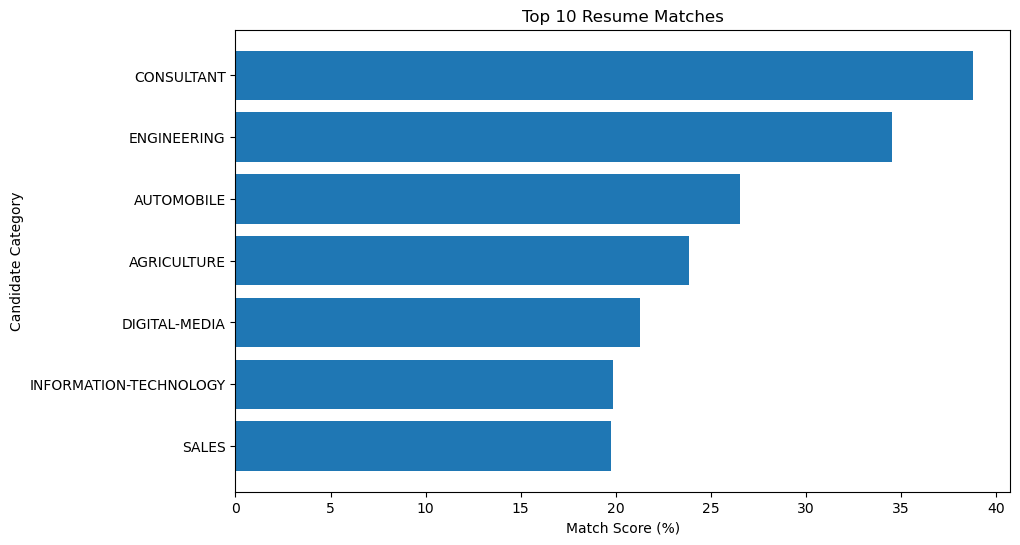

In [21]:
top10 = ranked_candidates[["Category", "Match_Score"]].head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Category"], top10["Match_Score"])

plt.xlabel("Match Score (%)")
plt.ylabel("Candidate Category")
plt.title("Top 10 Resume Matches")

plt.gca().invert_yaxis()

plt.show()

In [22]:
ranked_candidates[["Category", "Match_Score"]].head(10).to_csv(
    "top_10_ranked_candidates.csv",
    index=False
)

print("Top 10 ranked candidates saved successfully!")

Top 10 ranked candidates saved successfully!


# Business Insights

This Resume Screening System helps recruiters automatically compare resumes with a job description.

The system uses NLP and cosine similarity to calculate a match score for each resume. Candidates with higher scores are ranked higher because their resume contains more relevant skills and keywords related to the job role.

For the Data Scientist role, the system identified the best matching candidates and also showed missing skills such as Git, NumPy, Pandas, and NLP.

This can help HR teams shortlist candidates faster, reduce manual screening time, and make hiring decisions more consistent.